# Data Validation

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
df = pd.read_csv("data/restructured_data.csv")
df.head()

,LOG_ID,MRN,hypoxemia,crp,co2,glucose,hematocrit,hemoglobin,leukocytes,potassium,sodium,pH,lactate,age,sex,bmi,height,weight
0,0004678c0906bb9e,6b03d87f76b29311,0,7.6,23.0,119.0,27.8,9.2,6.2,4.4,130.0,NaN,NaN,70,0,24.170546,1.651000,65.884098
1,0011abe1d4cc9915,c28fd59799fdb891,0,NaN,24.0,121.0,26.7,8.4,8.0,4.2,141.0,NaN,NaN,69,0,23.346969,1.778000,73.806400
2,00126ebdaa3f286a,f3ef9a2e287a78e8,0,15.9,27.0,106.0,36.7,12.4,9.8,3.7,141.0,7.42,NaN,83,0,25.200019,1.803400,81.956800
3,0013fc9808033c8f,ef268d8abece3181,0,NaN,26.0,122.0,39.5,14.0,5.7,4.5,137.0,NaN,NaN,79,0,28.384024,1.753221,87.246353
4,001656cc37a919fd,73ae956471950fd0,0,0.3,23.0,96.0,38.7,12.9,8.4,3.8,138.0,NaN,NaN,23,1,35.843942,1.549400,86.048414


### 1. Checking duplicate encounter keys

In [45]:
dup_n = df.duplicated(subset=["LOG_ID", "MRN"]).sum()

if dup_n == 0:
    print("No duplicated encounter keys found.")
else:
    print(f"Found {dup_n} duplicated encounter keys.")

No duplicated encounter keys found.


### 2. Verifying required columns are present

In [46]:
KEY_COLS =  ["LOG_ID", "MRN"]
OUTCOME_COL = ["hypoxemia"]
LAB_COLS = ["crp", "co2", "glucose", "hematocrit", "hemoglobin",
           "leukocytes", "potassium", "sodium", "pH", "lactate"]
DEMO_COLS = ["age", "sex", "bmi", "height", "weight"]

REQUIRED_COLS = KEY_COLS + OUTCOME_COL + LAB_COLS + DEMO_COLS

missing_cols = [col for col in REQUIRED_COLS if col not in df.columns]

if len(missing_cols) == 0:
    print("All required columns are present.")
else:
    print("Missing required columns:")
    print(missing_cols)

All required columns are present.


### 3. Checking expected data types

In [47]:
string_cols = ["LOG_ID", "MRN"]
non_string_cols = [
    col for col in string_cols
    if not pd.api.types.is_string_dtype(df[col])
]
if len(non_string_cols) == 0:
    print("All expected string columns have valid data types.")
else:
    print("These columns are not string type:")
    print(non_string_cols)

numeric_cols = LAB_COLS + [col for col in DEMO_COLS if col != "sex"]
non_numeric_cols = [
    col for col in numeric_cols
    if not pd.api.types.is_numeric_dtype(df[col])
]
if len(non_numeric_cols) == 0:
    print("All expected numeric columns have valid data types.")
else:
    print("These columns are not numeric type:")
    print(non_numeric_cols)

binary_cols = ["hypoxemia", "sex"]
invalid_binary_cols = []
for col in binary_cols:
    values = df[col].dropna().unique()
    if (not pd.api.types.is_numeric_dtype(df[col])) or (not set(values).issubset({0, 1})):
        invalid_binary_cols.append(col)
if len(invalid_binary_cols) == 0:
    print("All expected binary columns have valid data types and values.")
else:
    print("These binary columns have invalid data types or values:")
    print(invalid_binary_cols)

All expected string columns have valid data types.
All expected numeric columns have valid data types.
All expected binary columns have valid data types and values.


### 4. Screening for implausible values

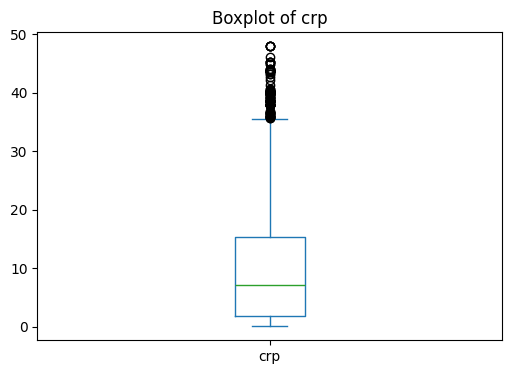

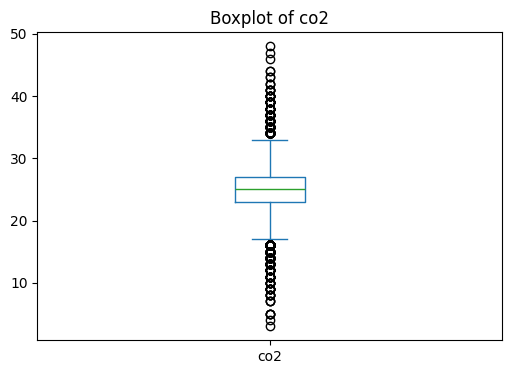

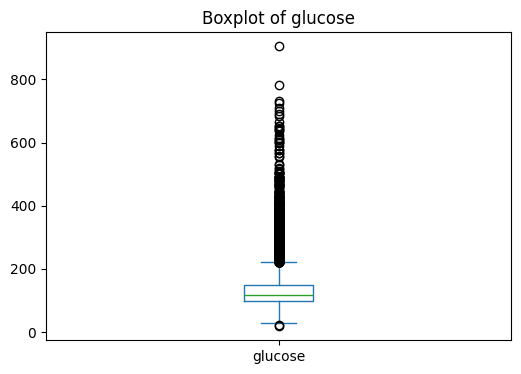

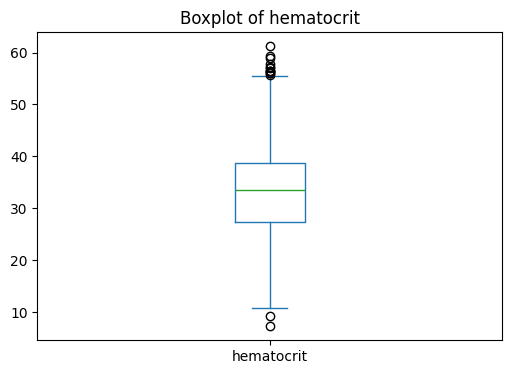

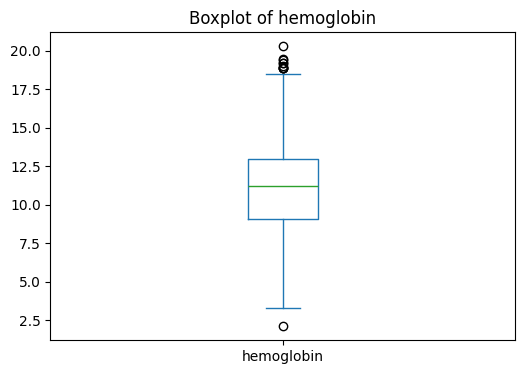

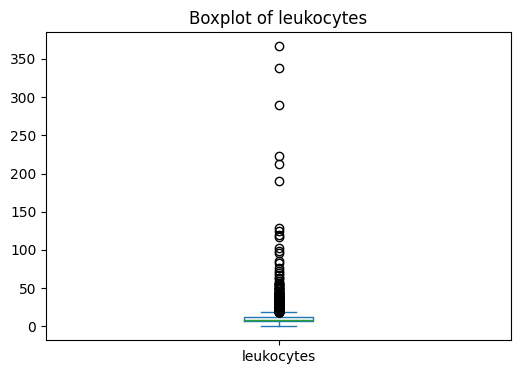

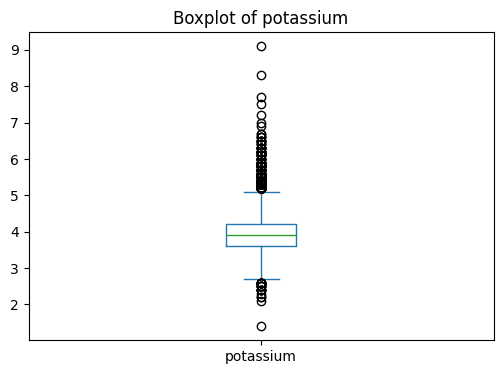

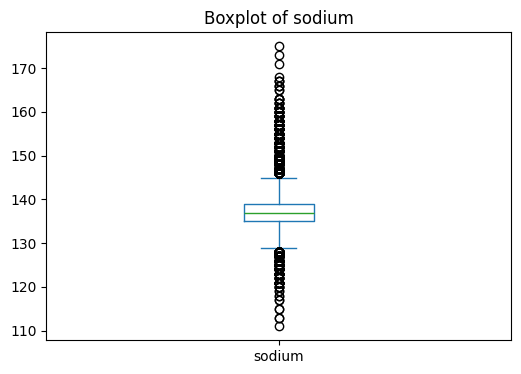

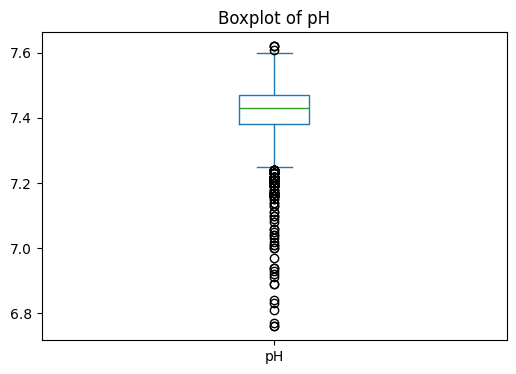

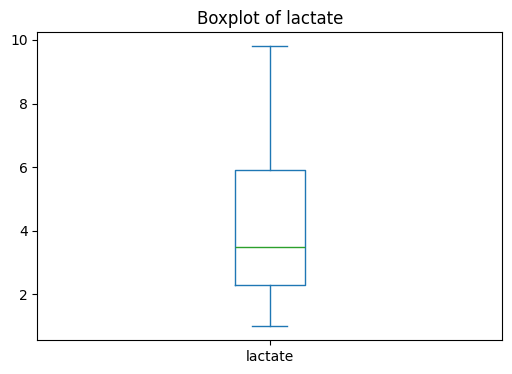

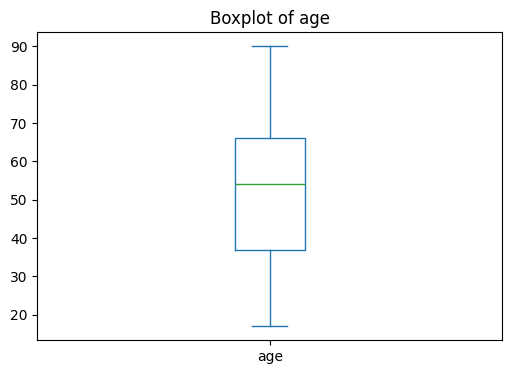

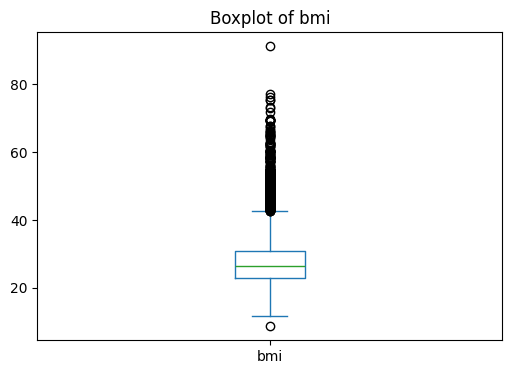

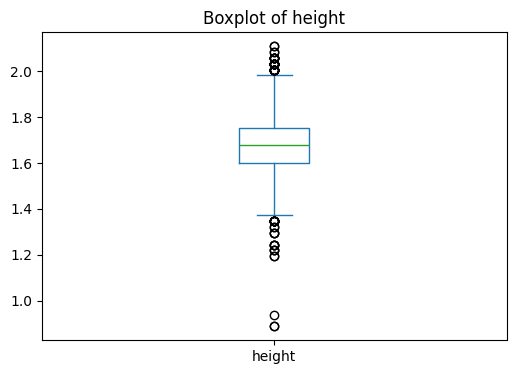

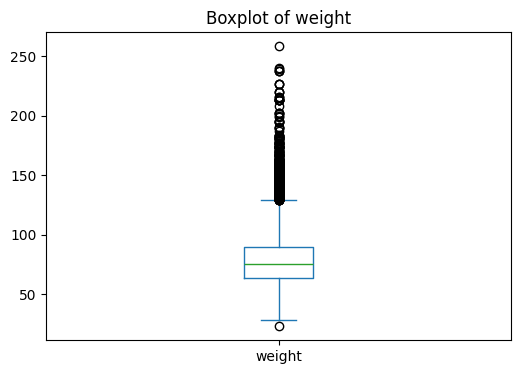

In [48]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].plot(kind="box")
    plt.title(f"Boxplot of {col}")
    plt.show()

In [50]:
df["hypoxemia"].value_counts(dropna=False)

hypoxemia
0    24151
1       16
Name: count, dtype: int64

In [51]:
df["sex"].value_counts(dropna=False)

sex
0    14403
1     9764
Name: count, dtype: int64

In [55]:
cols = ["hypoxemia", "sex"]

df[cols].apply(lambda x: x.value_counts(dropna=False)).T

,0,1
hypoxemia,24151,16
sex,14403,9764


### 5. Missing value checks

In [52]:
missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": df.isna().mean() * 100
})

missing_summary

,n_missing,pct_missing
LOG_ID,0,0.000000
MRN,0,0.000000
hypoxemia,0,0.000000
crp,19553,80.907850
co2,902,3.732362
glucose,900,3.724087
hematocrit,353,1.460670
hemoglobin,360,1.489635
leukocytes,416,1.721356
potassium,887,3.670294
